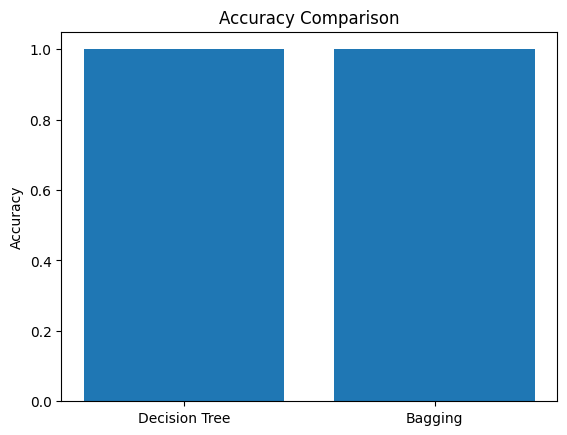

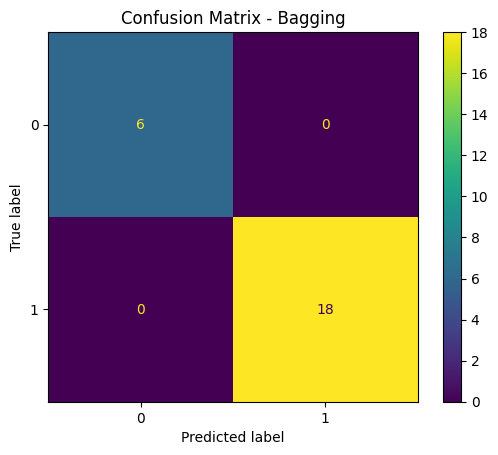

In [1]:
#24BAD128-EXP 6-Scenario 1
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

data = pd.read_csv("/content/sample_data/diabetes_bagging.csv")

X = data.drop("Outcome", axis=1)
y = data["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

bag = BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=50, random_state=42)
bag.fit(X_train, y_train)
y_pred_bag = bag.predict(X_test)

acc_dt = accuracy_score(y_test, y_pred_dt)
acc_bag = accuracy_score(y_test, y_pred_bag)

plt.bar(["Decision Tree", "Bagging"], [acc_dt, acc_bag])
plt.title("Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

cm = confusion_matrix(y_test, y_pred_bag)
ConfusionMatrixDisplay(cm).plot()
plt.title("Confusion Matrix - Bagging")
plt.show()

AdaBoost Accuracy: 0.9375
Gradient Boosting Accuracy: 0.9375


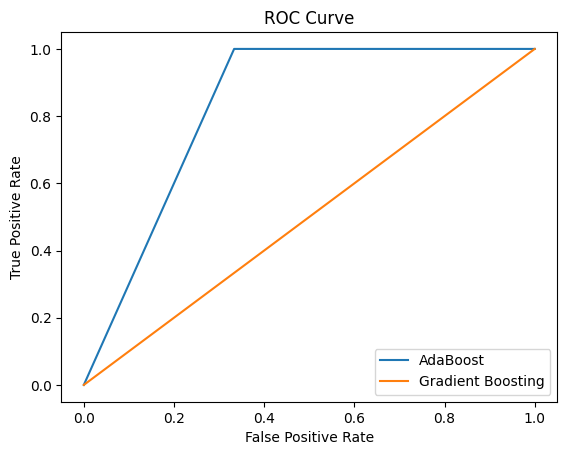

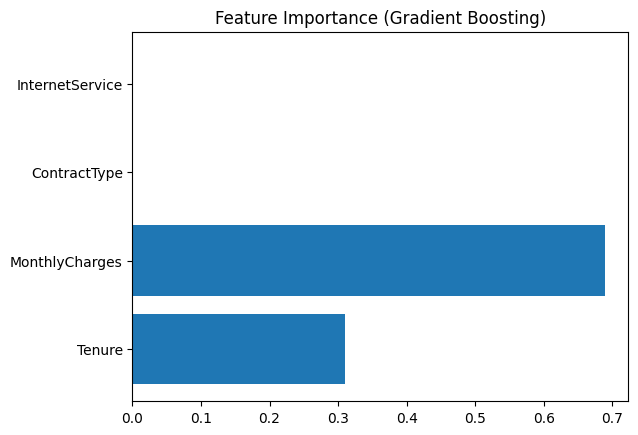

In [2]:
##24BAD128-EXP 6-Scenario 2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, roc_curve, auc

df = pd.read_csv("/content/sample_data/churn_boosting.csv")

df = df.dropna()
df = df.replace(" ", "")

le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

X = df.drop("Churn", axis=1)
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

ada = AdaBoostClassifier()
ada.fit(X_train, y_train)
y_pred_ada = ada.predict(X_test)

gb = GradientBoostingClassifier()
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)

print("AdaBoost Accuracy:", accuracy_score(y_test, y_pred_ada))
print("Gradient Boosting Accuracy:", accuracy_score(y_test, y_pred_gb))

ada_prob = ada.predict_proba(X_test)[:,1]
gb_prob = gb.predict_proba(X_test)[:,1]

fpr1, tpr1, _ = roc_curve(y_test, ada_prob)
fpr2, tpr2, _ = roc_curve(y_test, gb_prob)

plt.plot(fpr1, tpr1, label="AdaBoost")
plt.plot(fpr2, tpr2, label="Gradient Boosting")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

plt.barh(X.columns, gb.feature_importances_)
plt.title("Feature Importance (Gradient Boosting)")
plt.show()

Columns:
 Index(['Age', 'EducationYears', 'HoursPerWeek', 'Experience', 'Income'], dtype='object')

Default Random Forest Accuracy: 1.0


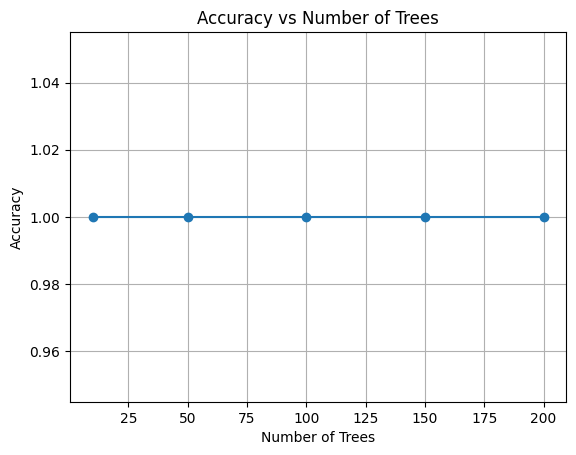

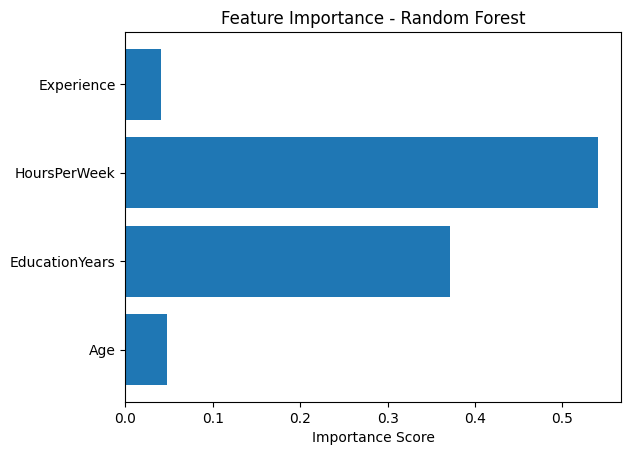

In [3]:

#24BAD128-EXP 6-Scenario 3
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

df = pd.read_csv("/content/sample_data/income_random_forest.csv")

print("Columns:\n", df.columns)

target_col = "Income"

X = df.drop(target_col, axis=1)
y = df[target_col]

#Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#Train Random Forest (default)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
acc_default = accuracy_score(y_test, y_pred)

print("\nDefault Random Forest Accuracy:", acc_default)

#Tune Number of Trees
trees = [10, 50, 100, 150, 200]
accuracies = []

for n in trees:
    model = RandomForestClassifier(n_estimators=n, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)

#Accuracy vs Number of Trees Graph
plt.figure()
plt.plot(trees, accuracies, marker='o')
plt.title("Accuracy vs Number of Trees")
plt.xlabel("Number of Trees")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

#Feature Importance
importances = rf.feature_importances_
features = X.columns

plt.figure()
plt.barh(features, importances)
plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance Score")
plt.show()

Columns:
 Index(['Age', 'Cholesterol', 'MaxHeartRate', 'RestingBP', 'HeartDisease'], dtype='object')

Logistic Regression Accuracy: 0.8333333333333334
SVM Accuracy: 0.875
Decision Tree Accuracy: 0.9583333333333334
Stacking Accuracy: 0.9583333333333334


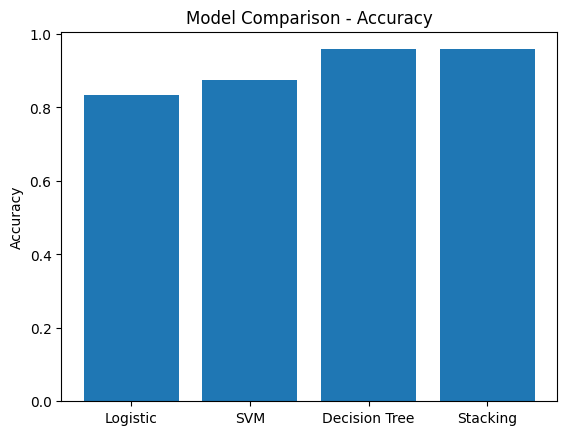

In [4]:
#24BAD128-EXP 6-Scenario 4
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.metrics import accuracy_score

df = pd.read_csv("/content/sample_data/heart_stacking.csv")

print("Columns:\n", df.columns)

df.dropna(inplace=True)

le = LabelEncoder()
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

#Target column handling
#Common names in heart dataset
if "target" in df.columns:
    target_col = "target"
elif "HeartDisease" in df.columns:
    target_col = "HeartDisease"
elif "Outcome" in df.columns:
    target_col = "Outcome"
else:
    raise Exception("Target column not found")

#Features & target
X = df.drop(target_col, axis=1)
y = df[target_col]

scaler = StandardScaler()
X = scaler.fit_transform(X)

#Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#Base Models
lr = LogisticRegression()
svm = SVC(probability=True)
dt = DecisionTreeClassifier()

#Train individual models
lr.fit(X_train, y_train)
svm.fit(X_train, y_train)
dt.fit(X_train, y_train)

#Predictions
lr_pred = lr.predict(X_test)
svm_pred = svm.predict(X_test)
dt_pred = dt.predict(X_test)

#Accuracy
lr_acc = accuracy_score(y_test, lr_pred)
svm_acc = accuracy_score(y_test, svm_pred)
dt_acc = accuracy_score(y_test, dt_pred)

#Stacking Model
estimators = [
    ('lr', LogisticRegression()),
    ('svm', SVC(probability=True)),
    ('dt', DecisionTreeClassifier())
]

stack_model = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression()
)

stack_model.fit(X_train, y_train)

stack_pred = stack_model.predict(X_test)
stack_acc = accuracy_score(y_test, stack_pred)

#Print Results
print("\nLogistic Regression Accuracy:", lr_acc)
print("SVM Accuracy:", svm_acc)
print("Decision Tree Accuracy:", dt_acc)
print("Stacking Accuracy:", stack_acc)

#Visualization - Model Comparison
models = ["Logistic", "SVM", "Decision Tree", "Stacking"]
accuracies = [lr_acc, svm_acc, dt_acc, stack_acc]

plt.bar(models, accuracies)
plt.title("Model Comparison - Accuracy")
plt.ylabel("Accuracy")
plt.show()

Columns:
 Index(['Amount', 'Time', 'Feature1', 'Feature2', 'Fraud'], dtype='object')

Class Distribution BEFORE SMOTE:
Fraud
0    110
1     10
Name: count, dtype: int64


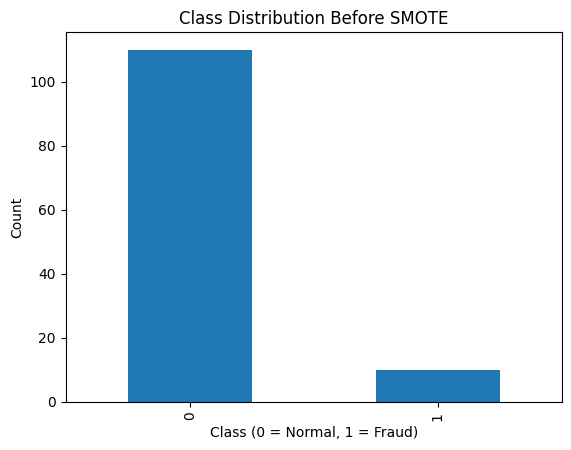


Class Distribution AFTER SMOTE:
Fraud
0    88
1    88
Name: count, dtype: int64


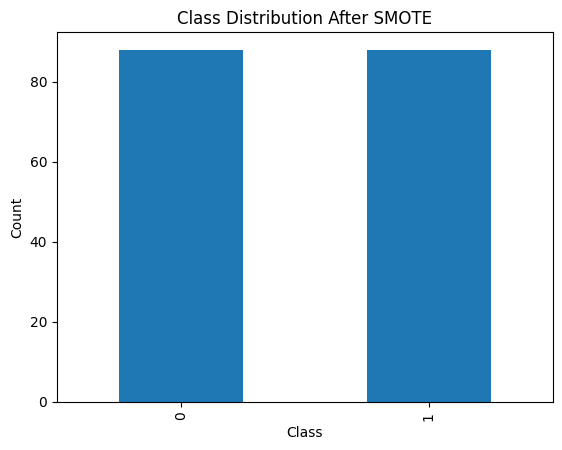


Accuracy BEFORE SMOTE: 0.9166666666666666
Accuracy AFTER SMOTE: 0.8333333333333334


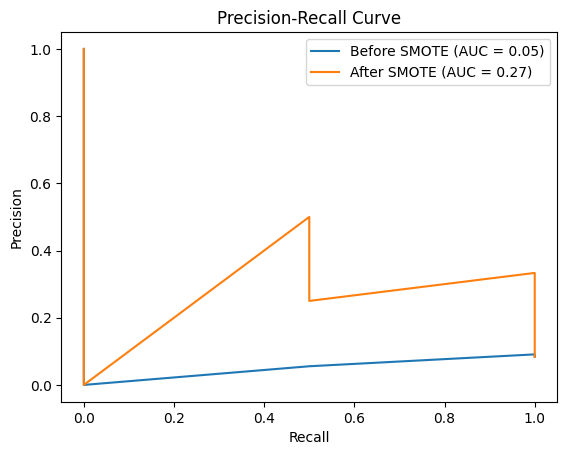

In [5]:
#24BAD128-EXP 6-Scenario 5
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_recall_curve, auc

from imblearn.over_sampling import SMOTE

df = pd.read_csv("/content/sample_data/fraud_smote.csv")

print("Columns:\n", df.columns)

target_col = "Fraud"

X = df.drop(target_col, axis=1)
y = df[target_col]

#Check Class Imbalance
print("\nClass Distribution BEFORE SMOTE:")
print(y.value_counts())

#Plot BEFORE SMOTE
y.value_counts().plot(kind='bar')
plt.title("Class Distribution Before SMOTE")
plt.xlabel("Class (0 = Normal, 1 = Fraud)")
plt.ylabel("Count")
plt.show()

#Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#Model BEFORE SMOTE
model_before = RandomForestClassifier(random_state=42)
model_before.fit(X_train, y_train)

y_pred_before = model_before.predict(X_test)
y_prob_before = model_before.predict_proba(X_test)[:, 1]

acc_before = accuracy_score(y_test, y_pred_before)

#Apply SMOTE
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("\nClass Distribution AFTER SMOTE:")
print(pd.Series(y_train_sm).value_counts())

#Plot AFTER SMOTE
pd.Series(y_train_sm).value_counts().plot(kind='bar')
plt.title("Class Distribution After SMOTE")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

#Model AFTER SMOTE
model_after = RandomForestClassifier(random_state=42)
model_after.fit(X_train_sm, y_train_sm)

y_pred_after = model_after.predict(X_test)
y_prob_after = model_after.predict_proba(X_test)[:, 1]

acc_after = accuracy_score(y_test, y_pred_after)

#Print Accuracy
print("\nAccuracy BEFORE SMOTE:", acc_before)
print("Accuracy AFTER SMOTE:", acc_after)

#Precision-Recall Curve
prec_before, rec_before, _ = precision_recall_curve(y_test, y_prob_before)
prec_after, rec_after, _ = precision_recall_curve(y_test, y_prob_after)

pr_auc_before = auc(rec_before, prec_before)
pr_auc_after = auc(rec_after, prec_after)

plt.plot(rec_before, prec_before, label="Before SMOTE (AUC = %0.2f)" % pr_auc_before)
plt.plot(rec_after, prec_after, label="After SMOTE (AUC = %0.2f)" % pr_auc_after)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()